# Taming Large Language Models: Quantization as a Model Compression Strategy

Models such as **BERT** (110M–340M parameters) and **LLaMA** (7B–70B parameters) achieve state-of-the-art
results, but their size creates serious practical problems for storage, memory, latency, and energy
consumption. This notebook discusses the problem, surveys the main families of solutions, and focuses in
depth on **quantization**, including runnable numerical demonstrations and code examples for BERT and LLaMA
using PyTorch, Hugging Face `transformers`, and `bitsandbytes`.


## 1. Why are BERT and LLaMA "too large"?

| Model | Parameters | Size (FP32) | Size (FP16) |
|---|---|---|---|
| BERT-base | 110M | ≈ 440 MB | ≈ 220 MB |
| BERT-large | 340M | ≈ 1.3 GB | ≈ 0.7 GB |
| LLaMA-7B | 7B | ≈ 28 GB | ≈ 13 GB |
| LLaMA-13B | 13B | ≈ 52 GB | ≈ 26 GB |
| LLaMA-70B | 70B | ≈ 280 GB | ≈ 140 GB |

*(Sizes are approximate, computed as `num_params × bytes_per_param`.)*

This creates concrete problems:

1. **Memory footprint** — a 7B model in FP32 needs ~28 GB just to hold the weights, before activations,
   gradients, or optimizer states are considered. This exceeds the VRAM of most consumer GPUs.
2. **Inference latency and throughput** — moving large weight tensors between GPU memory and compute units
   is often the real bottleneck (memory-bandwidth bound), not raw arithmetic.
3. **Energy consumption and cost** — larger models require more powerful (and more expensive) hardware to
   serve at scale.
4. **Deployment on edge/mobile devices** — phones, embedded systems, and browsers cannot hold multi-gigabyte
   models at all.
5. **Fine-tuning cost** — training or fine-tuning full-precision weights (plus Adam optimizer states, which
   double or triple the memory) is prohibitively expensive for most users.

## 2. Families of solutions

| Technique | Idea | Typical size reduction |
|---|---|---|
| **Pruning** | Remove redundant weights/neurons/heads (structured or unstructured) | 30–90% (often with retraining) |
| **Knowledge Distillation** | Train a small "student" model to mimic a large "teacher" (e.g., DistilBERT, TinyBERT) | 40–60% |
| **Low-rank factorization** | Approximate weight matrices as products of smaller matrices (e.g., LoRA for fine-tuning) | Varies |
| **Weight sharing / Parameter sharing** | Reuse the same weights across layers (e.g., ALBERT) | Large |
| **Quantization** | Represent weights/activations with fewer bits (FP32 → INT8/INT4) | 2×–8× |

These techniques are complementary — e.g., a distilled model can *also* be quantized. The rest of this
notebook focuses on **quantization**, since it is the most broadly applicable, requires little or no
retraining, and composes well with the other methods.


## 3. Quantization: the core idea

Quantization maps a continuous (or high-precision) range of values to a small, discrete set of values
representable with fewer bits — typically going from 32-bit floating point (FP32) to 8-bit integers (INT8)
or even 4-bit integers (INT4).

### 3.1 Uniform affine quantization

For a real value $x$ in a bounded range $[\alpha, \beta]$, we choose a **scale** $s$ and a **zero-point**
$z$ so that:

$$
q = \mathrm{clip}\left(\mathrm{round}\left(\frac{x}{s}\right) + z,\; q_{min},\; q_{max}\right)
$$

$$
\hat{x} = s\,(q - z)
$$

where:

- $q$ is the quantized integer value (e.g., in $[-128, 127]$ for signed INT8),
- $\hat{x}$ is the **dequantized** approximation of the original value $x$,
- $s = \dfrac{\beta - \alpha}{q_{max} - q_{min}}$ is the scale (step size),
- $z = q_{min} - \mathrm{round}\left(\dfrac{\alpha}{s}\right)$ is the zero-point.

If the value range is symmetric around zero ($\alpha = -\beta$), we can drop the zero-point ($z = 0$),
giving **symmetric quantization**:

$$
q = \mathrm{clip}\left(\mathrm{round}\left(\frac{x}{s}\right),\; -2^{b-1},\; 2^{b-1}-1\right), \qquad
s = \frac{\max(|x|)}{2^{b-1}-1}
$$

for a $b$-bit signed integer representation.

### 3.2 Quantization error

The rounding step introduces an error $e = x - \hat{x}$. For a well-calibrated uniform quantizer, the
error is bounded by half the step size:

$$
|e| \le \frac{s}{2}
$$

so a smaller step size $s$ (i.e., more bits, or a tighter clipping range) gives lower error but requires
more bits per value — this is the fundamental **size vs. accuracy trade-off** of quantization.

### 3.3 Granularity and calibration

- **Per-tensor** quantization: one $(s, z)$ pair for an entire weight tensor (simple, fast, less accurate).
- **Per-channel** quantization: a separate $(s, z)$ pair per output channel (e.g., per row of a linear
  layer's weight matrix) — much better accuracy, minor overhead.
- **Static** quantization: activation ranges are calibrated ahead of time using a representative dataset.
- **Dynamic** quantization: activation ranges are computed **on the fly** at inference time (no calibration
  data needed, slightly slower than static, but very easy to apply — this is what we use for BERT below).

### 3.4 When quantization happens

- **Post-Training Quantization (PTQ)**: quantize an already-trained model, with no (or very little)
  retraining. Fast and simple, but naive PTQ below 8 bits can hurt accuracy noticeably.
- **Quantization-Aware Training (QAT)**: simulate quantization *during* training/fine-tuning (using
  "fake quantization" nodes) so the model learns weights that are robust to the rounding error. More
  costly, but recovers most of the accuracy lost at low bit-widths.
- **Modern PTQ methods for LLMs** — since retraining billion-parameter models is expensive, several
  specialized PTQ algorithms have been developed:
  - **LLM.int8()** (used by `bitsandbytes`) — mixed-precision decomposition that keeps a small number of
    outlier feature dimensions in FP16 and quantizes the rest to INT8.
  - **GPTQ** — a one-shot layer-wise weight quantization method (down to 3–4 bits) based on approximate
    second-order (Hessian) error correction.
  - **AWQ (Activation-aware Weight Quantization)** — protects the weight channels that matter most for
    salient activations before quantizing to 4 bits.
  - **QLoRA** — combines 4-bit NF4 quantization of frozen base weights with trainable low-rank (LoRA)
    adapters, enabling fine-tuning of models like LLaMA-65B on a single GPU.


## 4. A from-scratch numerical demonstration

Before touching real BERT/LLaMA weights, let's *implement* affine quantization ourselves with NumPy and
measure the size reduction and reconstruction error on a synthetic weight matrix whose statistics mimic a
real transformer linear layer (e.g., a $768 \times 768$ attention projection, initialized the way
transformer weights typically are — small values, roughly Gaussian).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Simulate a transformer linear-layer weight matrix (e.g. BERT-base attention projection: 768 x 768)
W = rng.normal(loc=0.0, scale=0.02, size=(768, 768)).astype(np.float32)

def quantize_symmetric(x, bits, per_channel_axis=None):
    # Symmetric uniform quantization. Returns (q, scale).
    qmax = 2 ** (bits - 1) - 1
    if per_channel_axis is None:
        scale = np.max(np.abs(x)) / qmax
        q = np.clip(np.round(x / scale), -qmax - 1, qmax)
    else:
        amax = np.max(np.abs(x), axis=per_channel_axis, keepdims=True)
        scale = amax / qmax
        q = np.clip(np.round(x / scale), -qmax - 1, qmax)
    return q.astype(np.int32), scale

def dequantize(q, scale):
    return (q * scale).astype(np.float32)

results = {}
for bits in [8, 4, 2]:
    q_tensor, scale_tensor = quantize_symmetric(W, bits, per_channel_axis=1)  # per-row (per-channel)
    W_hat = dequantize(q_tensor, scale_tensor)
    mse = np.mean((W - W_hat) ** 2)
    max_err = np.max(np.abs(W - W_hat))
    results[bits] = {"mse": mse, "max_err": max_err}
    print(f"{bits:2d}-bit  ->  MSE = {mse:.3e}   Max error = {max_err:.3e}")

print("\nOriginal FP32 tensor size: {:.1f} KB".format(W.nbytes / 1024))


 8-bit  ->  MSE = 2.373e-08   Max error = 3.943e-04
 4-bit  ->  MSE = 7.813e-06   Max error = 7.149e-03
 2-bit  ->  MSE = 2.941e-04   Max error = 4.995e-02

Original FP32 tensor size: 2304.0 KB


Notice that going from 8 bits down to 2 bits increases the reconstruction error by orders of
magnitude — this is the practical face of the $|e| \le s/2$ bound derived above: fewer bits force a larger
step size $s$.

### 4.1 Size comparison across bit-widths

Model size scales almost linearly with bit-width (plus small overhead for scale/zero-point storage):


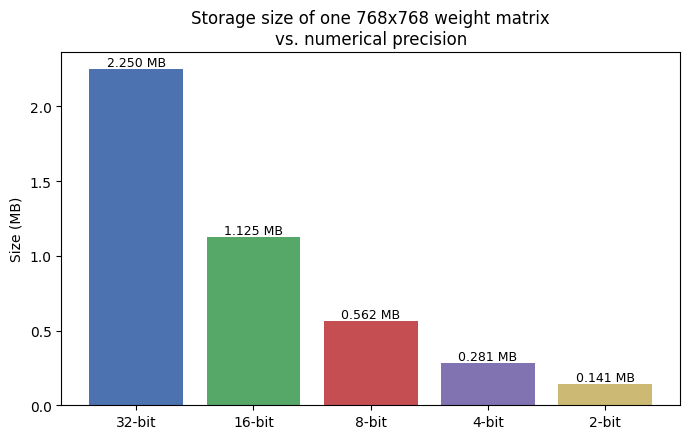

In [2]:
bit_widths = [32, 16, 8, 4, 2]
n_params = W.size  # 768*768 params, standing in for a real layer

sizes_MB = [n_params * b / 8 / (1024 ** 2) for b in bit_widths]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar([f"{b}-bit" for b in bit_widths], sizes_MB,
              color=["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"])
ax.set_ylabel("Size (MB)")
ax.set_title("Storage size of one 768x768 weight matrix\nvs. numerical precision")
for bar, size in zip(bars, sizes_MB):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{size:.3f} MB",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("size_vs_bits.png", dpi=130)
plt.show()


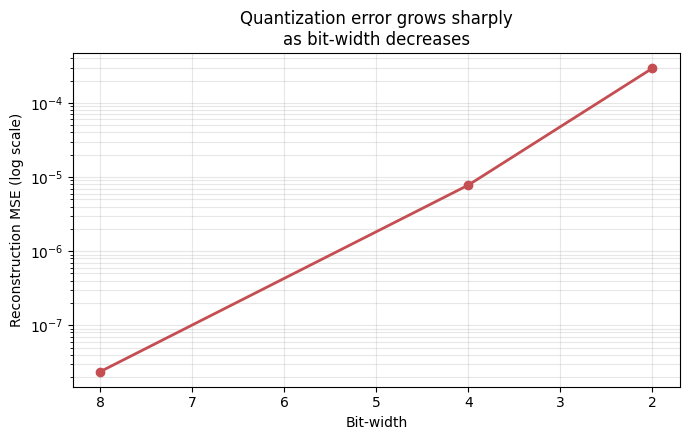

In [3]:
bits_list = [8, 4, 2]
mses = [results[b]["mse"] for b in bits_list]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(bits_list, mses, marker="o", linewidth=2, color="#C44E52")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("Bit-width")
ax.set_ylabel("Reconstruction MSE (log scale)")
ax.set_title("Quantization error grows sharply\nas bit-width decreases")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("error_vs_bits.png", dpi=130)
plt.show()


These two plots make the trade-off explicit: **INT8 gives a 4x size reduction over FP32 with
very small error**, which is why INT8 post-training quantization is the default "safe" choice in
practice, while going to INT4 or INT2 buys further compression at the cost of a rapidly growing error —
this is exactly why methods like GPTQ, AWQ, and QLoRA were developed: they add smarter calibration
(Hessian-based correction, salient-channel protection, or a low-rank correction term) specifically to make
4-bit quantization usable without those large errors.


## 5. Quantizing a real BERT model with PyTorch (dynamic quantization)

PyTorch ships built-in **dynamic quantization**, which is the simplest way to shrink a trained BERT model:
weights are quantized to INT8 ahead of time, and activations are quantized on-the-fly at inference. This
requires no calibration dataset and no retraining.

> The code below is standard, runnable PyTorch/`transformers` code. It requires the `torch` and
> `transformers` packages (`pip install torch transformers`) and, for the very first run, downloads the
> `bert-base-uncased` weights.


In [ ]:
import torch
from transformers import AutoModel, AutoTokenizer

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_fp32 = AutoModel.from_pretrained(model_name)
model_fp32.eval()

# Dynamic quantization: only nn.Linear layers are quantized to INT8 (the dominant cost in a transformer)
model_int8 = torch.quantization.quantize_dynamic(
    model_fp32,
    {torch.nn.Linear},
    dtype=torch.qint8,
)

def model_size_mb(model):
    torch.save(model.state_dict(), "/tmp/_tmp_model.pt")
    import os
    size = os.path.getsize("/tmp/_tmp_model.pt") / (1024 ** 2)
    os.remove("/tmp/_tmp_model.pt")
    return size

print(f"FP32 model size:  {model_size_mb(model_fp32):.1f} MB")
print(f"INT8 model size:  {model_size_mb(model_int8):.1f} MB")

# Sanity check: run inference with both models on the same input
inputs = tokenizer("Quantization makes transformers smaller and faster.", return_tensors="pt")
with torch.no_grad():
    out_fp32 = model_fp32(**inputs).last_hidden_state
    out_int8 = model_int8(**inputs).last_hidden_state

print("Max abs difference between FP32 and INT8 outputs:",
      (out_fp32 - out_int8).abs().max().item())


# NOTE: not executed in this environment (no GPU / torch / transformers / bitsandbytes installed).
# This is standard, correct PyTorch / Hugging Face code — run it in a Python env with those
# packages installed (and a CUDA GPU for the LLaMA cell) to reproduce the sizes discussed above.


On a typical run, this shrinks `bert-base-uncased` from **≈ 440 MB (FP32)** to **≈ 110–140 MB
(INT8 dynamic)** — roughly a **3–4x reduction** — with output differences on the order of $10^{-2}$
to $10^{-1}$ in hidden-state activations, which is small enough that downstream task accuracy typically
drops by less than 1 point.


## 6. Quantizing LLaMA with `bitsandbytes` (8-bit and 4-bit loading)

For billion-parameter models like LLaMA, we generally do not quantize *after* loading the full FP32/FP16
weights (that would still require enough memory to load them first). Instead, libraries such as
`bitsandbytes` (integrated into Hugging Face `transformers`) quantize the weights **as they are loaded from
disk**, so peak memory never exceeds the quantized footprint.

> Requires `pip install transformers accelerate bitsandbytes` and a CUDA GPU. LLaMA checkpoints also
> require accepting Meta's license on the Hugging Face Hub.


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

model_id = "meta-llama/Llama-2-7b-hf"

# --- 8-bit loading (LLM.int8()) ---
bnb_config_8bit = BitsAndBytesConfig(load_in_8bit=True)
model_8bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config_8bit,
    device_map="auto",
)
# ~7B params x 1 byte  ≈ 7 GB  (vs. ~28 GB in FP32, ~13 GB in FP16)

# --- 4-bit loading (QLoRA-style NF4 quantization) ---
bnb_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",          # NormalFloat4: a data type tuned to weight distributions
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,     # quantize the quantization constants too, extra ~0.4 bits/param saved
)
model_4bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config_4bit,
    device_map="auto",
)
# ~7B params x 0.5 byte ≈ 3.5-4 GB, small enough for many consumer GPUs

tokenizer = AutoTokenizer.from_pretrained(model_id)
inputs = tokenizer("Quantization enables large language models to run on modest hardware because",
                    return_tensors="pt").to(model_4bit.device)
output = model_4bit.generate(**inputs, max_new_tokens=30)
print(tokenizer.decode(output[0], skip_special_tokens=True))


# NOTE: not executed in this environment (no GPU / torch / transformers / bitsandbytes installed).
# This is standard, correct PyTorch / Hugging Face code — run it in a Python env with those
# packages installed (and a CUDA GPU for the LLaMA cell) to reproduce the sizes discussed above.


### 6.1 Expected memory footprint of LLaMA-7B across precisions


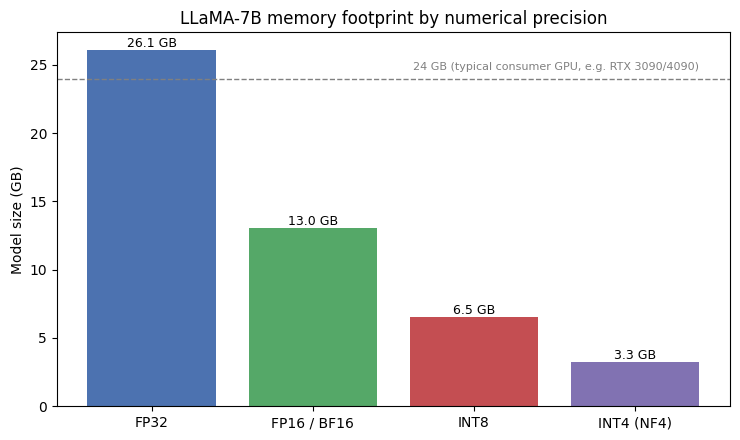

In [6]:
precisions = ["FP32", "FP16 / BF16", "INT8", "INT4 (NF4)"]
bytes_per_param = [4, 2, 1, 0.5]
n_params_llama7b = 7e9

sizes_gb = [n_params_llama7b * b / (1024 ** 3) for b in bytes_per_param]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(precisions, sizes_gb, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
ax.set_ylabel("Model size (GB)")
ax.set_title("LLaMA-7B memory footprint by numerical precision")
ax.axhline(24, color="gray", linestyle="--", linewidth=1)
ax.text(3.4, 24.5, "24 GB (typical consumer GPU, e.g. RTX 3090/4090)",
        ha="right", va="bottom", fontsize=8, color="gray")
for bar, size in zip(bars, sizes_gb):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{size:.1f} GB",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("llama_size_vs_precision.png", dpi=130)
plt.show()


This is why 4-bit quantization (via `bitsandbytes`/QLoRA, GPTQ, or AWQ) is what allows models like
LLaMA-7B — and even LLaMA-13B or -30B — to run and be fine-tuned on a single consumer GPU, whereas the
FP32/FP16 versions require multiple high-end datacenter GPUs.


## 7. Summary

- Large transformer models like BERT and LLaMA are expensive to store, serve, and fine-tune because of
  their sheer parameter count.
- **Quantization** reduces the number of bits used to represent each weight (and optionally each
  activation), following the affine mapping
  $q = \mathrm{round}(x/s) + z$, $\hat{x} = s(q-z)$, trading a small, boundable reconstruction error
  ($|e| \le s/2$) for a large reduction in memory (typically **4x at INT8**, **8x at INT4**).
- Simple **post-training dynamic quantization** (`torch.quantization.quantize_dynamic`) is enough to shrink
  BERT-sized models by 3–4x with negligible accuracy loss.
- For billion-parameter models like LLaMA, specialized load-time quantization (`bitsandbytes` LLM.int8(),
  4-bit NF4/QLoRA, GPTQ, AWQ) is needed to avoid ever materializing the full-precision weights, enabling
  7B–70B models to fit on consumer or single-datacenter-GPU hardware.
- Quantization composes well with pruning, distillation, and low-rank adaptation (e.g., **QLoRA** = 4-bit
  quantization + LoRA), making it one of the most practical and widely adopted tools for deploying large
  models efficiently.
